### Detailed Arch of RNNs
* Components of an RNN
    * Input Layer
        * Takes sequential data as input at each time step
    * Hidden Layer
        * maintains a memory of past inputs through connections recurrent connections. The hidden state at time t(h_t) is calculated as 
            * h_t = f(W_h. h_(t-1) + W_x . x_t + b_h)
                * W_h weight matric for recurrent connetions
                * W_x weight matrix ofrt input conenctions
                * b_h : Bias terms
                * f: Non linear activation function (eg, tanh, ReLU)
    * Output Layer
        * prduces the output y_t, based on the hidden state h_t
            * y_t = g(W_y . h_t + b_y)
                * g: Activation function (eg,softmax for classification)
### Backpropagation through time (BPTT)
* What is BPTT
    * Extension of standard backpropagation to handle sequential data in RNNs
    * It calculates the gradients for each time step and propagrates them backward through the sequence
    * Steps of BPTT
        * Backpropagate the errors across all time steps to update weights
        * Compute the loss for each time step
        * backpropagate the eroros across all time steps to  update weights
    * Challenges in BPTT
        * vanishing gradient problem
            * Gradients diminsh exponentially as they propageted back through time
            * Leads to difficulty in learning long-term dependencies
        * Exploding Gradient Problem
            * Gradients grow exponentially , causing numerical instability during training
    * Solutions
        * Use gradients clipping to handle exploding gradients
        * Use architecture like Long Short-Term Memory(LSTM) or Gated Recurrent Units (GRU) to mitigate the vanishing gradients problems 

### Limitations of Vanilla RNNS
* Short Term Memory
    * struggle to learn dependencies in long squences due to vanishing gradients
* Sequential Computation
    * Cannot paralleize training across time steps making them computationally expensive
* Sensitive Initialization
    * Performance depends heavily on proper weight initialization and learning rates
    


In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import tensorflow as tf

In [3]:
VOCAB_SIZE=10000
MAX_LEN = 200


In [4]:
(X_train, y_train),(X_test,y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post")

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")



Training Data Shape: (25000, 200)
Test Data Shape: (25000, 200)


In [5]:
# Build and train RNN model
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,output_dim=128),
    SimpleRNN(128, activation="tanh", return_sequences=False),
    Dense(1, activation="sigmoid")
])
# compile the model

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
hostory = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)
loss, accuracy = model.evaluate(X_test, y_test)



Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 144ms/step - accuracy: 0.5077 - loss: 0.6984 - val_accuracy: 0.5168 - val_loss: 0.6876
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.5431 - loss: 0.6821 - val_accuracy: 0.5502 - val_loss: 0.6754
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.5749 - loss: 0.6634 - val_accuracy: 0.5372 - val_loss: 0.6829
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.5870 - loss: 0.6445 - val_accuracy: 0.5442 - val_loss: 0.6907
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.5953 - loss: 0.6299 - val_accuracy: 0.5462 - val_loss: 0.6907
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5540 - loss: 0.6916


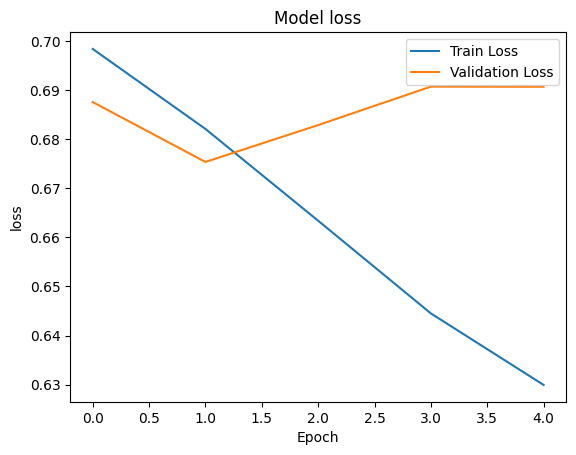

In [8]:
import matplotlib.pyplot as plt

plt.plot(hostory.history["loss"],label="Train Loss",)
plt.plot(hostory.history["val_loss"], label="Validation Loss")
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
VOCAB_SIZE=10000
MAX_LEN = 200

In [3]:
(X_train, y_train),(X_test,y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post")

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")


Training Data Shape: (25000, 200)
Test Data Shape: (25000, 200)


In [5]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle= True)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNNModel,self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self,x):
        embedded = self.embedding(x)
        output, hidden = self.rnn (embedded)
        return torch.sigmoid(self.fc(hidden.squeeze(0)))
    
model = RNNModel(VOCAB_SIZE,128,128,1)



In [2]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

def train_rnn(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch).squeeze(1)
            loss = criterion(predictions,y_batch.float())
            loss.backward()
            optimizer.step()
            epoch_loss+= loss.item()
        print(f"Epoch {epoch+1}, LOSS: {epoch_loss/len(train_loader)}")

train_rnn(model,train_loader,criterion,optimizer)

NameError: name 'nn' is not defined

In [1]:
def evaluate_rnn(model, X_test, y_train):
    model.eval()
    with torch.no_grad():
        predictions= model(torch.tensor(X_test).squeeze(1),)
        loss = criterion(predictions, torch.tensor(y_test).float())
        accuracy = ((predictions>0)== torch.tensor(y_test).float()).float().mean().item()

    print(f"Test Loss: {loss.item()} Test Accuracy: {accuracy}")
evaluate_rnn(model,X_test, y_test)

NameError: name 'model' is not defined